# 2026 Local Government Elections: eThekwini Metro Forecasting Solution
**Course:** TLPR200 Final Exam 2026 | **Student:**Nelisa Mdubo | **Student no.:** 22418646

**Purpose.** Used official IEC results for the 2011, 2016 and 2021 municipal elections to estimate, for 04 November 2026: (1) the largest party vote share/total and will  any party passes 50%, (2) the leading party in three wards, (3) vote totals/shares per party, (4) voter turnout.Making sure that is **not** a political opinion and **not** a prediction of who will govern.

**Expectations:** problem framing, data acquisition, understanding and preparation,ward boundary alignment, EDA, modelling, temporal validation, diagnostics, dashboard, complexity analysis.



**Problem Statement**

Estimating future election results in eThekwini is challenging because party support, voter turnout and ward boundaries can change between elections. Historical results provide useful information, but these changes make it difficult to assume that previous voting patterns will continue.

This project uses the 2011, 2016 and 2021 municipal election datasets to analyse voting patterns and estimate possible outcomes for 2026. It focuses on party vote shares and totals, whether any party could receive more than 50% of valid ward votes, the likely leading parties in three selected wards, and voter turnout under different scenarios.

The project involves cleaning and organising the data, comparing areas across election years, identifying trends, and testing prediction methods against known historical results. The findings are presented in an interactive dashboard that clearly separates historical results from future estimates.

 The aim is to provide an understandable analysis of possible election outcomes, with clear explanations of model performance and uncertainty, rather than a guaranteed prediction of who will govern.

Importing pandas to be able to read the cvs file
numpy helps with number
Importinf matplotlin ans seaborn to be able to draw and design graphs
Path and os helps find files and foldes


In [84]:
import warnings, json, os, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
try:
    display
except NameError:
    display = print
RNG = np.random.default_rng(42)



#  configuration
METRO = "eThekwini"
FILES = {2011: "/content/ETH_Ward 2011.csv", 2016: "/content/ETH_Ward 2016.csv", 2021: "/content/ETH_Ward 2021.csv"}
BALLOT = "Ward"
COUNCIL_SEATS = 222
REGISTERED_2026 = None
LAMBDA = 0.5
MIN_PARTY_SHARE = 0.01
SELECTED_WARDS = None
SOURCES = [
    {"name": "IEC municipal election results, detailed results by voting district (ETH_Ward_2011/2016/2021.csv)",
     "url": "https://results.elections.org.za/home/Downloads/ME-Results", "downloaded": "YYYY-MM-DD", "file": "ETH_Ward_20xx.csv"},
    {"name": "Municipal Demarcation Board, ward delimitation", "url": "https://www.demarcation.org.za/", "downloaded": "YYYY-MM-DD", "file": "reference only"},
]
print("Data folder:", DATA_DIR)

Data folder: /content/drive/MyDrive/Final exam/data


In [85]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/outputs",
    "zip",
    str(OUT_DIR)
)

files.download("/content/outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Printing out the first 5 rows from the 2021 file and I've observed that 2016 has more voters than any other 2021 and 2011
I've also obsevered that data is pretty similar in all columns besides the Total valid votes

In [86]:
data_2011 = pd.read_csv(
    "/content/ETH_Ward 2011.csv",
    encoding="utf-16"
)

data_2016 = pd.read_csv("/content/ETH_Ward 2016.csv")
data_2021 = pd.read_csv("/content/ETH_Ward 2021.csv")

print("2011 rows and columns:", data_2011.shape)
print("2016 rows and columns:", data_2016.shape)
print("2021 rows and columns:", data_2021.shape)
display(data_2021.head())

2011 rows and columns: (11226, 11)
2016 rows and columns: (40706, 11)
2021 rows and columns: (32990, 11)


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ABANTU BATHO CONGRESS,19,11/23/2021 4:11:07 PM
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACADEMIC CONGRESS UNION,0,11/23/2021 4:11:07 PM
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACTIONSA,0,11/23/2021 4:11:07 PM
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0,11/23/2021 4:11:07 PM
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ADVANCED DYNAMIC ALLIANCE,0,11/23/2021 4:11:07 PM


## Data understanding
The three CSV files are IEC detailed results for the eThekwini metro: **one row per party per voting district (VD) per ballot type**. Facts established by inspection (re-verified in the cells below):
- The 2011 file is encoded in **UTF-16** (a naive `read_csv` returns garbage), the others are UTF-8. The loader detects the byte-order mark.
- `RegisteredVoters` and `SpoiltVotes` are repeated on every party row of a VD, so they must be unduplicated or drop the duplicates before summing (summing the raw column would multiply them by the number of parties).
- The 2016 file holds both **PR** and **Ward** ballots; 2011 and 2021 hold only **Ward**. Only the Ward ballot is comparable across all three cycles, so it is used throughout. A consequence: PR-ballot totals (which decide PR seats) are not modelled.
- The `INDEPENDENT` label pools all independent ward candidates into one category. `AFRICAN INDEPENDENT CONGRESS` is a real party and must not be merged into it.

This cell reads the files and checks thier structer
Clearly defines the different obects and integers


In [87]:
def read_any(path):
    p = Path(path)
    if p.is_dir():
        raise IsADirectoryError(f"{p} is a folder. Point to the file inside it.")
    if p.suffix.lower() in (".xlsx", ".xls"):
        return pd.read_excel(p), "excel"
    head = open(p, "rb").read(4)
    encs = ("utf-16",) if head[:2] in (b"\xff\xfe", b"\xfe\xff") else ("utf-8", "utf-8-sig", "latin-1")
    for enc in encs:
        try:
            return pd.read_csv(p, encoding=enc, low_memory=False), enc
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Could not decode {p}")

print("Files in data folder:", sorted(os.listdir(DATA_DIR)) if DATA_DIR.exists() else "MISSING FOLDER")
raw = {}
for y, f in FILES.items():
    raw[y], enc = read_any(DATA_DIR / f)
    print(f"{y}: {raw[y].shape[0]:,} rows x {raw[y].shape[1]} cols, encoding={enc}, ballot types={raw[y].BallotType.value_counts().to_dict()}")
display(raw[2021].head(4))
print(raw[2021].dtypes)

Files in data folder: MISSING FOLDER
2011: 11,226 rows x 11 cols, encoding=utf-16, ballot types={'Ward': 11226}
2016: 40,706 rows x 11 cols, encoding=utf-8, ballot types={'PR': 23382, 'Ward': 17324}
2021: 32,990 rows x 11 cols, encoding=utf-8, ballot types={'Ward': 32990}


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ABANTU BATHO CONGRESS,19,11/23/2021 4:11:07 PM
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACADEMIC CONGRESS UNION,0,11/23/2021 4:11:07 PM
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACTIONSA,0,11/23/2021 4:11:07 PM
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0,11/23/2021 4:11:07 PM


Province             object
Municipality         object
Ward                 object
VotingDistrict        int64
VotingStationName    object
RegisteredVoters      int64
BallotType           object
SpoiltVotes           int64
PartyName            object
TotalValidVotes       int64
DateGenerated        object
dtype: object


##  Preprocessing
Steps: keep the Ward ballot; extract the numeric ward id; make ancronyms of party names across cycles (the DA appears under two spellings, spacing differs); drop duplicates and invalid values; build two clean tables:
- `vl`: valid votes per **year, ward, voting district, party**;
- `ui`: one row per **year, ward, voting district** with registered voters, spoilt and valid votes, votes cast and turnout (`(valid + spoilt) / registered`).

Nothing is imputed or invented. Checks are printed so differences can be explained.

Alias give the parties shorter names or thier acronyms

The prep function makes a copy of the data,removes extra spaces,keeps the ward ballots and makes party names consistent

The checks look for missing numbers, duplicates, negative votes, and conflicting district information.




In [88]:
ALIAS = {"AFRICAN NATIONAL CONGRESS": "ANC", "DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE": "DA", "DEMOCRATIC ALLIANCE": "DA",
         "INKATHA FREEDOM PARTY": "IFP", "ECONOMIC FREEDOM FIGHTERS": "EFF", "MINORITY FRONT": "MF",
         "NATIONAL FREEDOM PARTY": "NFP", "INDEPENDENT": "INDEPENDENTS"}

def prep(df, year):
    d = df.copy(); d.columns = [c.strip() for c in d.columns]
    d = d[d.BallotType.astype(str).str.strip().str.upper() == BALLOT.upper()].copy()
    d["ward"] = d.Ward.astype(str).str.replace("Ward", "", case=False).str.strip()
    d["vd"] = d.VotingDistrict.astype(str).str.strip()
    d["party"] = d.PartyName.astype(str).str.upper().str.replace(r"\s+", " ", regex=True).str.strip().replace(ALIAS)
    d["year"] = year
    return d

D = {y: prep(raw[y], y) for y in FILES}
chk = []
for y, d in D.items():
    chk.append(dict(year=y, rows=len(d), wards=d.ward.nunique(), voting_districts=d.vd.nunique(), parties=d.party.nunique(),
                    dup_rows=int(d.duplicated().sum()), dup_vd_party=int(d.duplicated(["ward", "vd", "party"]).sum()),
                    registered_not_constant_in_vd=int((d.groupby("vd").RegisteredVoters.nunique() > 1).sum()),
                    vd_in_several_wards=int((d.groupby("vd").ward.nunique() > 1).sum()),
                    negative_votes=int((d.TotalValidVotes < 0).sum()), missing=int(d[["TotalValidVotes", "RegisteredVoters", "SpoiltVotes"]].isna().sum().sum())))
display(pd.DataFrame(chk).set_index("year"))
df = pd.concat(D.values(), ignore_index=True).drop_duplicates()
df = df[(df.TotalValidVotes >= 0) & df.RegisteredVoters.notna()]

# Group tiny parties (below MIN_PARTY_SHARE in every cycle) as OTHER
tot = df.groupby(["year", "party"]).TotalValidVotes.sum()
sh = (tot / tot.groupby(level=0).transform("sum")).unstack(0).fillna(0)
KEEP = sh.index[(sh >= MIN_PARTY_SHARE).any(axis=1)].tolist()
df["party"] = np.where(df.party.isin(KEEP), df.party, "OTHER")
PARTIES = sorted(set(df.party)); print("Parties modelled:", PARTIES)

vl = df.groupby(["year", "ward", "vd", "party"], as_index=False).TotalValidVotes.sum().rename(columns={"TotalValidVotes": "votes"})
ui = (df.drop_duplicates(["year", "ward", "vd"])[["year", "ward", "vd", "VotingStationName", "RegisteredVoters", "SpoiltVotes"]]
        .rename(columns={"RegisteredVoters": "registered", "SpoiltVotes": "spoilt"}))
ui = ui.merge(vl.groupby(["year", "vd"], as_index=False).votes.sum().rename(columns={"votes": "valid_votes"}), on=["year", "vd"])
ui["votes_cast"] = ui.valid_votes + ui.spoilt
ui["turnout"] = ui.votes_cast / ui.registered

rec = ui.groupby("year").agg(voting_districts=("vd", "nunique"), registered=("registered", "sum"), valid_votes=("valid_votes", "sum"),
                             spoilt=("spoilt", "sum"), votes_cast=("votes_cast", "sum"), vd_turnout_gt_1=("turnout", lambda s: int((s > 1).sum())))
rec["turnout_rate"] = rec.votes_cast / rec.registered
rec["spoilt_pct"] = rec.spoilt / rec.votes_cast
display(rec.round(4))
p16 = raw[2016][raw[2016].BallotType == "PR"].TotalValidVotes.sum(); w16 = raw[2016][raw[2016].BallotType == "Ward"].TotalValidVotes.sum()
print(f"Reconciliation note (2016): valid Ward-ballot votes {w16:,} vs PR-ballot {p16:,}. They differ because they are separate ballots; the Ward ballot is used consistently.")

,rows,wards,voting_districts,parties,dup_rows,dup_vd_party,registered_not_constant_in_vd,vd_in_several_wards,negative_votes,missing
year,,,,,,,,,,
2011,11226,103,801,19,0,0,0,0,0,0
2016,17324,110,866,28,0,0,0,0,0,0
2021,32990,111,875,53,0,0,0,0,0,0


Parties modelled: ['ACTIONSA', 'ACTIVE CITIZENS COALITION', 'AFRICAN INDEPENDENT CONGRESS', 'ANC', 'DA', 'EFF', 'IFP', 'INDEPENDENTS', 'MF', 'NFP', 'OTHER']


,voting_districts,registered,valid_votes,spoilt,votes_cast,vd_turnout_gt_1,turnout_rate,spoilt_pct
year,,,,,,,,
2011,801,1666549,968553,15755,984308,0,0.5906,0.0160
2016,866,1919724,1121053,20298,1141351,1,0.5945,0.0178
2021,875,1909125,776015,14503,790518,1,0.4141,0.0183


Reconciliation note (2016): valid Ward-ballot votes 1,121,053 vs PR-ballot 1,104,552. They differ because they are separate ballots; the Ward ballot is used consistently.


## Geographic and temporary alignment
**Observation** : Ward numbers are **not** guaranteed to cover the same land across elections because wards are re-delimited before each election (the Municipal Demarcation Board changed ward counts and boundaries between cycles; this metro has 103, 110 and 111 wards in the three files). The same  ward labels can therefore hide different areas.

**Strategy.** Ward boundaries can change between elections, so I used voting-district IDs to match areas across the three datasets. This makes comparisons more consistent, although matching IDs does not guarantee that district boundaries stayed exactly the same. For historical ward comparisons, I only treated wards as comparable when their voting-district lists had a Jaccard overlap of at least 90%. Since the supplied data did not include the 2026 ward map, I used the 2021 ward arrangement for the 2026 predictions and clearly labelled this assumption in the results.

Voting districts per cycle: {2011: 801, 2016: 866, 2021: 875}
VDs present in both 2011 and 2016: 799;  2016 and 2021: 863;  all three: 797
Wards (2021 labels) with >=90% identical VDs: 2016->2021: 58 of 111; across all three cycles: 17


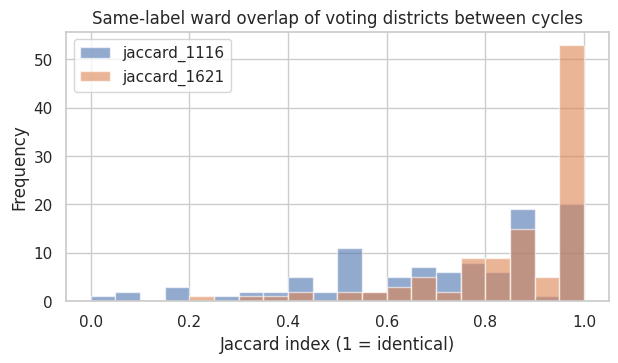

In [89]:
years = sorted(FILES); Y_a, Y_b, Y_c = years[-3], years[-2], years[-1]
vds = {y: set(ui[ui.year == y].vd) for y in years}
print("Voting districts per cycle:", {y: len(v) for y, v in vds.items()})
print(f"VDs present in both {Y_a} and {Y_b}: {len(vds[Y_a] & vds[Y_b])};  {Y_b} and {Y_c}: {len(vds[Y_b] & vds[Y_c])};  all three: {len(vds[Y_a] & vds[Y_b] & vds[Y_c])}")
def ward_sets(y): return ui[ui.year == y].groupby("ward").vd.apply(set)
def jac(a, b): return pd.Series({w: len(a[w] & b[w]) / len(a[w] | b[w]) for w in b.index if w in a.index})
wa, wb, wc = ward_sets(Y_a), ward_sets(Y_b), ward_sets(Y_c)
align = pd.DataFrame({"n_vd_2021": wc.apply(len)})
align["jaccard_1116"] = jac(wa, wb).reindex(align.index)
align["jaccard_1621"] = jac(wb, wc).reindex(align.index)
align["stable_1621"] = align.jaccard_1621 >= 0.9
align["stable_all"] = align.stable_1621 & (align.jaccard_1116 >= 0.9)
align = align.reset_index().rename(columns={"index": "ward"})
print(f"Wards (2021 labels) with >=90% identical VDs: {Y_b}->{Y_c}: {int(align.stable_1621.sum())} of {len(align)}; across all three cycles: {int(align.stable_all.sum())}")
fig, ax = plt.subplots(figsize=(7, 3.5)); align[["jaccard_1116", "jaccard_1621"]].plot.hist(bins=20, alpha=.6, ax=ax)
ax.set_title("Same-label ward overlap of voting districts between cycles"); ax.set_xlabel("Jaccard index (1 = identical)"); plt.show()

##  Exploratory data analysis

this cell turns the raw election counts into three facts the model needs:

**Vote shares:** it totals each party's votes across the whole metro for each year and converts them to shares, which gives a party-by-year table .
**Turnout:** it adds up registered voters, votes cast and valid votes per year, then divides votes cast by registered voters for the metro turnout rate.
**Charts:** it plots the top 8 parties' shares by year, the spread of turnout across voting districts (boxplot), and the overall turnout rate per year.
**Swing:** it subtracts each party's base-year share from its comparison-year share (in percentage points) and shows the three biggest falls and the three biggest gains.

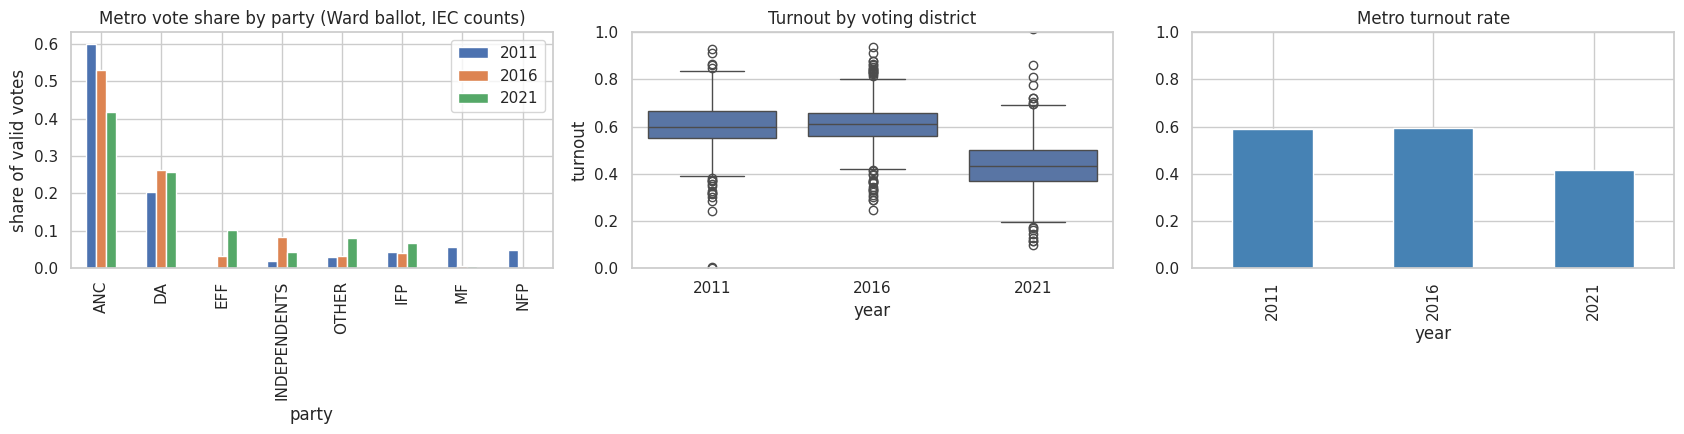

Metro turnout: 2011: 59.1%, 2016: 59.5%, 2021: 41.4%
Valid votes: {2011: 968553, 2016: 1121053, 2021: 776015} | Registered: {2011: 1666549, 2016: 1919724, 2021: 1909125}
Share swing 2016 to 2021 (pp), largest falls and gains:


party,ANC,INDEPENDENTS,AFRICAN INDEPENDENT CONGRESS,IFP,OTHER,EFF
swing_pp,-11.18,-4.08,-0.9,2.55,4.74,6.89


In [90]:
def metro_shares(year):
    v = vl[vl.year == year].groupby("party").votes.sum().reindex(PARTIES, fill_value=0)
    return v / v.sum()
S = pd.DataFrame({y: metro_shares(y) for y in years})
t_hist = ui.groupby("year").agg(registered=("registered", "sum"), votes_cast=("votes_cast", "sum"), valid_votes=("valid_votes", "sum"))
t_hist["turnout_rate"] = t_hist.votes_cast / t_hist.registered
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
S.loc[S.max(axis=1).sort_values(ascending=False).index[:8]].plot.bar(ax=ax[0]); ax[0].set_title("Metro vote share by party (Ward ballot, IEC counts)"); ax[0].set_ylabel("share of valid votes")
sns.boxplot(data=ui, x="year", y="turnout", ax=ax[1]); ax[1].set_title("Turnout by voting district"); ax[1].set_ylim(0, 1)
t_hist.turnout_rate.plot.bar(ax=ax[2], color="steelblue"); ax[2].set_title("Metro turnout rate"); ax[2].set_ylim(0, 1)
plt.tight_layout(); plt.show()
print(f"Metro turnout: " + ", ".join(f"{y}: {r:.1%}" for y, r in t_hist.turnout_rate.items()))
print("Valid votes:", t_hist.valid_votes.to_dict(), "| Registered:", t_hist.registered.to_dict())
sw = ((S[Y_c] - S[Y_b]) * 100).round(2).sort_values()
print(f"Share swing {Y_b} to {Y_c} (pp), largest falls and gains:"); display(pd.concat([sw.head(3), sw.tail(3)]).to_frame("swing_pp").T)

This cell moves from the metro-wide picture to a variation between voting districts and wards. The data is split into three levels: voting district (ui), ward (ws) and a ward-leader table (wm).
For each year, it computes the mean, median and standard deviation of registered voters, valid votes and turnout across voting districts. A big gap between mean and median means a few unusually large or small districts are pulling the average.
The IQR is the range covered by the middle half of districts. It is a spread measure that outliers don't distort, and it backs up the boxplot from the previous cell.**OBSERVATION**: The ANC is leading.


In [91]:
# Descriptive statistics: central tendency and variability
cols = ["registered", "valid_votes", "turnout"]
d = ui.groupby("year")[cols].agg(["mean", "median", "std"]).round(3); display(d)
iqr = ui.groupby("year").turnout.agg(lambda s: s.quantile(.75) - s.quantile(.25)).round(3); print("Turnout IQR by year:", iqr.to_dict())
ws = vl.groupby(["year", "ward", "party"], as_index=False).votes.sum()
ws["share"] = ws.votes / ws.groupby(["year", "ward"]).votes.transform("sum")
major = S[Y_c].sort_values(ascending=False).index[:5]
display(ws[ws.party.isin(major)].groupby(["year", "party"]).share.agg(["mean", "median", "std"]).round(3).unstack(0))
def top2(g):
    s = g.sort_values("share", ascending=False)
    return pd.Series(dict(leader=s.party.iloc[0], lead_share=s.share.iloc[0], margin=s.share.iloc[0] - (s.share.iloc[1] if len(s) > 1 else 0)))
wm = ws.groupby(["year", "ward"]).apply(top2).reset_index()
print("Wards led by each party:"); display(wm.groupby(["year", "leader"]).size().unstack(0).fillna(0).astype(int))

registered                   valid_votes                  turnout         \
           mean  median       std        mean  median      std    mean median   
year                                                                            
2011   2080.586  1981.0  1127.743    1209.180  1141.0  633.836   0.605  0.600   
2016   2216.771  2097.5  1219.851    1294.518  1237.5  674.624   0.611  0.609   
2021   2181.857  2054.0  1192.890     886.874   825.0  467.525   0.436  0.433   

             
        std  
year         
2011  0.094  
2016  0.088  
2021  0.103

Turnout IQR by year: {2011: 0.113, 2016: 0.097, 2021: 0.129}


mean               median                  std              
year    2011   2016   2021   2011   2016   2021   2011   2016   2021
party                                                               
ANC    0.600  0.542  0.438  0.667  0.550  0.461  0.274  0.236  0.218
DA     0.259  0.248  0.223  0.208  0.142  0.125  0.248  0.269  0.254
EFF      NaN  0.035  0.111    NaN  0.030  0.108    NaN  0.027  0.071
IFP    0.045  0.048  0.074  0.031  0.027  0.051  0.057  0.077  0.079
OTHER  0.030  0.031  0.076  0.024  0.016  0.059  0.023  0.040  0.063

Wards led by each party:


year,2011,2016,2021
leader,,,
ANC,78,73,75
DA,17,30,33
IFP,1,2,2
INDEPENDENTS,1,5,0
MF,6,0,0
OTHER,0,0,1


The ANC led 73 of 110 wards in 2016 and 75 of 111 in 2021, and the DA led 30 then 34. The ANC's metro share fell from about 53% to 42%, mostly because many 2016 ANC voters didn't vote in 2021 and smaller parties (EFF, ActionSA, independents) gained share. So lead counts barely moved while shares did.
The median winning margin fell from 0.45 to 0.33. Wards decided by under 10 points were 19 of 110 in 2016 and 14 of 111 in 2021, so there is a core of contested wards where a forecast will be uncertain.There is 1 voting district with turnout above 100% in each year and none with zero registered voters
The heatmap determines the correlationbetween each attributes

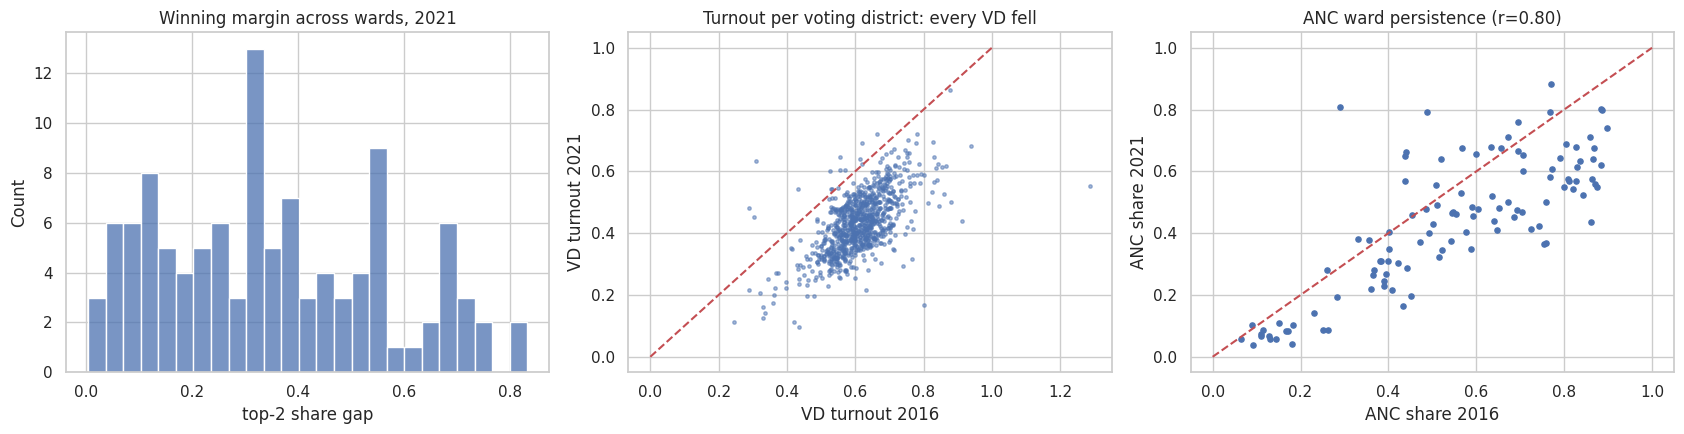

Turnout anomalies 2021 (|z|>3): 8 of 875 VDs;  VDs with turnout > 100%: 2


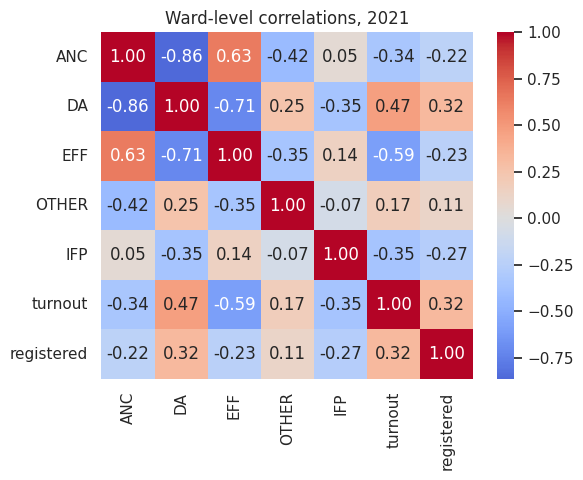

In [92]:
# Relationships, swings and anomalies
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(wm[wm.year == Y_c].margin, bins=25, ax=ax[0]); ax[0].set_title(f"Winning margin across wards, {Y_c}"); ax[0].set_xlabel("top-2 share gap")
tp = ui.pivot_table(index="vd", columns="year", values="turnout")
ax[1].scatter(tp[Y_b], tp[Y_c], s=6, alpha=.5); ax[1].plot([0, 1], [0, 1], "r--"); ax[1].set_xlabel(f"VD turnout {Y_b}"); ax[1].set_ylabel(f"VD turnout {Y_c}"); ax[1].set_title("Turnout per voting district: every VD fell")
lead = S[Y_c].idxmax(); pw = ws.pivot_table(index="ward", columns=["party", "year"], values="share")
sub = pw[[(lead, Y_b), (lead, Y_c)]].dropna(); r = sub.corr().iloc[0, 1]
ax[2].scatter(sub.iloc[:, 0], sub.iloc[:, 1], s=14); ax[2].plot([0, 1], [0, 1], "r--"); ax[2].set_xlabel(f"{lead} share {Y_b}"); ax[2].set_ylabel(f"{lead} share {Y_c}"); ax[2].set_title(f"{lead} ward persistence (r={r:.2f})")
plt.tight_layout(); plt.show()
u = ui[ui.year == Y_c]; z = (u.turnout - u.turnout.mean()) / u.turnout.std()
print(f"Turnout anomalies {Y_c} (|z|>3): {int((z.abs() > 3).sum())} of {len(u)} VDs;  VDs with turnout > 100%: {int((ui.turnout > 1).sum())}")
c21 = pd.DataFrame({p: ws[(ws.year == Y_c) & (ws.party == p)].set_index("ward").share for p in major}).join(u.groupby("ward").agg(turnout=("turnout", "mean"), registered=("registered", "sum")))
plt.figure(figsize=(6, 4.5)); sns.heatmap(c21.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0); plt.title(f"Ward-level correlations, {Y_c}"); plt.show()

## Ward selection (geographically defensible)
I used a clear rule to select three wards so that the historical comparisons would be more consistent. I first considered wards whose voting-district lists overlapped by at least 90% across all three elections. If fewer than six wards met this requirement, I used wards that met it between 2016 and 2021 and stated this change.

From the eligible wards, I selected one with a close contest, one with a winning margin near the middle, and one with the largest winning margin in 2021. This allows me to compare how the model performs in different situations. Other wards can be chosen using `SELECTED_WARDS`, provided the reason is explained.

In [93]:
pool = align[align.stable_all]; basis = "stable across all three cycles"
if len(pool) < 6:
    pool = align[align.stable_1621]; basis = "stable between 2016 and 2021 only (fewer than 6 wards were stable across all three cycles)"
cand = pool.merge(wm[wm.year == Y_c][["ward", "leader", "lead_share", "margin"]], on="ward").sort_values("margin").reset_index(drop=True)
print(f"Eligible wards: {len(cand)} ({basis})")
if SELECTED_WARDS:
    sel_list = [str(w) for w in SELECTED_WARDS]
elif len(cand) >= 3:
    sel_list = [cand.ward[0], cand.ward[len(cand) // 2], cand.ward[len(cand) - 1]]
else:
    sel_list = []; print("Fewer than 3 boundary-stable wards: report this and relax the stability threshold explicitly.")
selected = cand[cand.ward.isin(sel_list)].copy()
selected["why"] = ["most competitive" if w == sel_list[0] else "safest" if w == sel_list[-1] else "median margin" for w in selected.ward]
selected["selection_basis"] = basis
display(selected)

Eligible wards: 17 (stable across all three cycles)


,ward,n_vd_2021,jaccard_1116,jaccard_1621,stable_1621,stable_all,leader,lead_share,margin,why,selection_basis
0,59500026,5,1.000000,1.0,True,True,ANC,0.321633,0.004160,most competitive,stable across all three cycles
8,59500076,5,1.000000,1.0,True,True,ANC,0.608508,0.396607,median margin,stable across all three cycles
16,59500001,12,0.916667,1.0,True,True,ANC,0.881611,0.833446,safest,stable across all three cycles


##  Modelling
I used the three election datasets to check how well my methods predict past results before using them to estimate future outcomes.

For party vote shares, I assumed that part of the previous change in support would continue. I tested this by using the 2011 and 2016 results to estimate the 2021 results, then compared my estimates with what actually happened. I did not use ARIMA because three election years provide too little data for a reliable model.

To predict the leading party in each voting district, I trained a Random Forest using 2011 information and the actual 2016 leaders. I then tested it using 2016 information to predict the 2021 leaders. I also tested it across separate ward groups to see how well it worked in areas left out of training.

For turnout, I focused on whether districts remained above or below the municipality’s overall turnout. Since overall turnout changed considerably between elections, I used different future turnout scenarios rather than relying on one precise estimate.

In [94]:
def project(a, b, lam):
    p = (b + lam * (b - a)).clip(lower=0); return p / p.sum()
a, b, c = metro_shares(Y_a), metro_shares(Y_b), metro_shares(Y_c)
# Backtest: predict 2021 from 2011 and 2016, for several damping values
bt = []
for lam in [0, 0.25, 0.5, 0.75, 1.0]:
    e = c - project(a, b, lam)
    bt.append(dict(lambda_=lam, MAE_pp=100 * e.abs().mean(), RMSE_pp=100 * np.sqrt((e ** 2).mean()), max_abs_error_pp=100 * e.abs().max()))
bt = pd.DataFrame(bt).set_index("lambda_"); display(bt.round(3))
print("lambda=0 is the 'nothing changes' baseline. Only ONE backtest target exists (2021), so the choice of lambda is weakly supported; the scenario band below spans lambda 0 to 1 instead of trusting a single value.")
point = project(b, c, LAMBDA)
scen = pd.DataFrame({lam: project(b, c, lam) for lam in [0, 0.25, 0.5, 0.75, 1.0]})
swing_lo, swing_hi = scen.min(axis=1), scen.max(axis=1)
# Bootstrap over paired voting districts (sampling uncertainty only)
V = {y: vl[vl.year == y].pivot_table(index="vd", columns="party", values="votes", aggfunc="sum", fill_value=0).reindex(columns=PARTIES, fill_value=0) for y in (Y_b, Y_c)}
com = V[Y_b].index.intersection(V[Y_c].index); A0, A1 = V[Y_b].loc[com].values, V[Y_c].loc[com].values
boot = []
for _ in range(500):
    i = RNG.integers(0, len(com), len(com)); s0, s1 = A0[i].sum(0), A1[i].sum(0)
    boot.append(project(pd.Series(s0 / s0.sum(), PARTIES), pd.Series(s1 / s1.sum(), PARTIES), LAMBDA).values)
boot = np.array(boot)

,MAE_pp,RMSE_pp,max_abs_error_pp
lambda_,,,
0.00,3.096,4.501,11.183
0.25,3.071,4.015,8.438
0.50,2.977,3.698,6.872
0.75,2.887,3.644,8.145
1.00,2.801,3.831,9.360


lambda=0 is the 'nothing changes' baseline. Only ONE backtest target exists (2021), so the choice of lambda is weakly supported; the scenario band below spans lambda 0 to 1 instead of trusting a single value.


I used earlier party shares, turnout, and registration as inputs. I trained a Random Forest on the transition from 2011 to 2016, then tested it on the transition from 2016 to 2021. I compared it with two simple baselines and also checked performance across held-out ward groups. I measured the predictions using accuracy, precision, recall, F1, and a confusion matrix.

,accuracy,macro_precision,macro_recall,macro_f1
VD_winner_temporal_holdout,0.902,0.351,0.288,0.301
baseline_persistence_(last_winner_stays),0.867,0.373,0.314,0.326
baseline_majority_class,0.620,0.077,0.125,0.096
VD_winner_grouped_cv_2016to2021,0.893,0.288,0.315,0.301


Train accuracy (2011->2016): 0.99
                           precision    recall  f1-score   support

ACTIVE CITIZENS COALITION       0.00      0.00      0.00         2
                      ANC       0.89      0.98      0.94       535
                       DA       0.92      0.96      0.94       255
                      EFF       0.00      0.00      0.00         6
                      IFP       1.00      0.36      0.53        22
             INDEPENDENTS       0.00      0.00      0.00        29
                      NFP       0.00      0.00      0.00         1
                    OTHER       0.00      0.00      0.00        13

                 accuracy                           0.90       863
                macro avg       0.35      0.29      0.30       863
             weighted avg       0.85      0.90      0.87       863



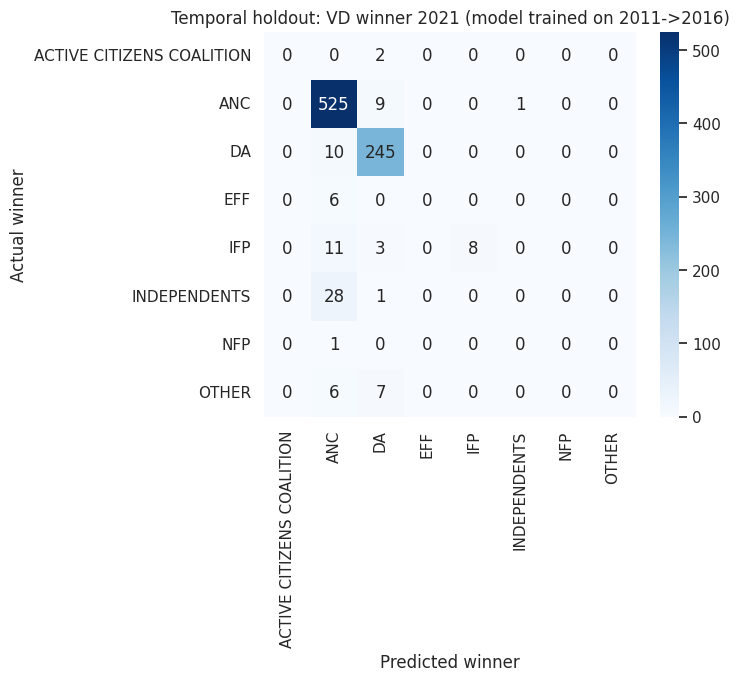

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error

def wide(year):
    p = vl[vl.year == year].pivot_table(index="vd", columns="party", values="votes", aggfunc="sum", fill_value=0).reindex(columns=PARTIES, fill_value=0)
    return p.div(p.sum(axis=1).replace(0, np.nan), axis=0)
def feats(year):
    s = wide(year).add_prefix("sh_"); u = ui[ui.year == year].set_index("vd")
    s["turnout"] = u.turnout.reindex(s.index); s["log_reg"] = np.log1p(u.registered.reindex(s.index)); return s
ward_of = {y: ui[ui.year == y].set_index("vd").ward for y in years}
valid_of = {y: ui[ui.year == y].set_index("vd").valid_votes for y in years}
def pair(prev, nxt):
    X, T = feats(prev), wide(nxt).idxmax(axis=1); idx = X.index.intersection(T.index)
    return X.loc[idx], T.loc[idx], ward_of[nxt].reindex(idx)
Xp1, yp1, gp1 = pair(Y_a, Y_b)      # 2011 -> 2016 (training period)
Xp2, yp2, gp2 = pair(Y_b, Y_c)      # 2016 -> 2021 (temporal test period)
new_rf = lambda: make_pipeline(SimpleImputer(strategy="median"), RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight="balanced", random_state=42))
def sc(y, p): return dict(accuracy=accuracy_score(y, p), macro_precision=precision_score(y, p, average="macro", zero_division=0),
                          macro_recall=recall_score(y, p, average="macro", zero_division=0), macro_f1=f1_score(y, p, average="macro", zero_division=0))

# --- B1. TEMPORAL holdout: fit on 2011->2016, test on 2016->2021 ---
rf1 = new_rf().fit(Xp1, yp1); pred2 = pd.Series(rf1.predict(Xp2), index=Xp2.index)
persist2 = Xp2.filter(like="sh_").idxmax(axis=1).str[3:]
majority2 = pd.Series(DummyClassifier(strategy="most_frequent").fit(Xp1, yp1).predict(Xp2), index=Xp2.index)
metrics = {"VD_winner_temporal_holdout": sc(yp2, pred2), "baseline_persistence_(last_winner_stays)": sc(yp2, persist2),
           "baseline_majority_class": sc(yp2, majority2), "train_accuracy_2011to2016": accuracy_score(yp1, rf1.predict(Xp1))}
# --- B2. ward-grouped CV within the 2016->2021 pair ---
cv = GroupKFold(n_splits=5); oof = pd.Series(cross_val_predict(new_rf(), Xp2, yp2, cv=cv, groups=gp2.values), index=Xp2.index)
metrics["VD_winner_grouped_cv_2016to2021"] = sc(yp2, oof)
display(pd.DataFrame({k: v for k, v in metrics.items() if isinstance(v, dict)}).T.round(3)); print("Train accuracy (2011->2016):", round(metrics["train_accuracy_2011to2016"], 3))
print(classification_report(yp2, pred2, zero_division=0))
labels = sorted(set(yp2) | set(pred2)); cmx = pd.DataFrame(confusion_matrix(yp2, pred2, labels=labels), index=labels, columns=labels)
plt.figure(figsize=(6, 5)); sns.heatmap(cmx, annot=True, fmt="d", cmap="Blues"); plt.xlabel("Predicted winner"); plt.ylabel("Actual winner"); plt.title("Temporal holdout: VD winner 2021 (model trained on 2011->2016)"); plt.show()
cmx.to_csv(OUT_DIR / "confusion.csv")

I combined the district model scores into ward scores, giving more weight to districts with more historical valid votes. I checked the ward predictions against the actual 2021 leaders and compared them with a simple persistence baseline. I then trained the final model on both historical transitions and used 2021 information to estimate 2026 leaders. I flagged close results as uncertain and used the 2021 ward arrangement because the supplied data did not include the 2026 map

In [96]:
# --- ward aggregation (probabilities -> ward leader), validated at WARD level on the 2021 holdout ---
def ward_aggregate(P, weights, wmap):
    t = P.mul(weights, axis=0).assign(_w=weights, ward=wmap.values).groupby("ward").sum()
    W = t[PARTIES].div(t["_w"], axis=0)
    info = W.apply(lambda r: pd.Series(dict(pred_leader=r.idxmax(), top_prob=r.max(), margin_prob=r.sort_values(ascending=False).iloc[0] - r.sort_values(ascending=False).iloc[1])), axis=1)
    return info, W
P2 = pd.DataFrame(rf1.predict_proba(Xp2), index=Xp2.index, columns=rf1.classes_).reindex(columns=PARTIES, fill_value=0)
info2, _ = ward_aggregate(P2, valid_of[Y_b].reindex(P2.index).fillna(1).clip(lower=1), gp2)
act = wm[wm.year == Y_c].set_index("ward").leader
common = info2.index.intersection(act.index)
base_prev = vl[(vl.year == Y_b) & vl.vd.isin(P2.index)].merge(gp2.rename("w21").reset_index(), on="vd").groupby(["w21", "party"]).votes.sum().unstack(fill_value=0).idxmax(axis=1)
metrics["ward_level_holdout"] = dict(model_accuracy=float((info2.loc[common, "pred_leader"] == act[common]).mean()),
                                    persistence_accuracy=float((base_prev.reindex(common) == act[common]).mean()), n_wards=int(len(common)),
                                    accuracy_on_confident_calls=float((info2.loc[common][info2.loc[common].margin_prob >= MARGIN_UNCERTAIN].pred_leader == act[common][info2.loc[common].margin_prob >= MARGIN_UNCERTAIN]).mean()),
                                    share_calls_uncertain=float((info2.loc[common].margin_prob < MARGIN_UNCERTAIN).mean()))
display(pd.Series(metrics["ward_level_holdout"]).round(3).to_frame("ward-level holdout (2021)").T)

# --- final model: pooled pairs, predict 2026 from 2021 features ---
rf = new_rf().fit(pd.concat([Xp1, Xp2]), pd.concat([yp1, yp2]))
X21 = feats(Y_c)
P = pd.DataFrame(rf.predict_proba(X21), index=X21.index, columns=rf.classes_).reindex(columns=PARTIES, fill_value=0)
info, WP = ward_aggregate(P, valid_of[Y_c].reindex(P.index).fillna(1).clip(lower=1), ward_of[Y_c].reindex(P.index))
wpred = info.join(WP.add_prefix("p_")); wpred["uncertain"] = wpred.margin_prob < MARGIN_UNCERTAIN
wpred = wpred.join(wm[wm.year == Y_c].set_index("ward")[["leader"]].rename(columns={"leader": f"leader_{Y_c}"}))
wpred["selected"] = wpred.index.isin(sel_list); wpred["boundary_basis"] = "2021 ward footprint"; wpred["record_type"] = "predicted_2026"
wpred = wpred.reset_index().rename(columns={"index": "ward"})
print(f"Uncertain ward calls: {int(wpred.uncertain.sum())} of {len(wpred)}.  Ward calls use the 2021 ward footprint.")
display(wpred[wpred.selected].round(3))

,model_accuracy,persistence_accuracy,n_wards,accuracy_on_confident_calls,share_calls_uncertain
ward-level holdout (2021),0.946,0.928,111.0,0.97,0.099


Uncertain ward calls: 13 of 111.  Ward calls use the 2021 ward footprint.


,ward,pred_leader,top_prob,margin_prob,p_ACTIONSA,p_ACTIVE CITIZENS COALITION,p_AFRICAN INDEPENDENT CONGRESS,p_ANC,p_DA,p_EFF,p_IFP,p_INDEPENDENTS,p_MF,p_NFP,p_OTHER,uncertain,leader_2021,selected,boundary_basis,record_type
0,59500001,ANC,0.826,0.750,0.0,0.008,0.0,0.826,0.055,0.008,0.003,0.076,0.0,0.000,0.023,False,ANC,True,2021 ward footprint,predicted_2026
25,59500026,DA,0.465,0.198,0.0,0.106,0.0,0.267,0.465,0.043,0.064,0.040,0.0,0.001,0.014,False,ANC,True,2021 ward footprint,predicted_2026
75,59500076,ANC,0.604,0.472,0.0,0.016,0.0,0.604,0.064,0.079,0.070,0.132,0.0,0.008,0.027,False,ANC,True,2021 ward footprint,predicted_2026


**Reading the validation evidence.** Compare the temporal-holdout scores with the persistence baseline: a model that does not beat "last winner stays" has added nothing. A large gap between training accuracy and holdout accuracy signals overfitting. The ward-level table shows how often confident calls were right in 2021 and what share of calls were flagged uncertain. Also note the covariate shift: parties that first contested in 2021 (e.g. ACTIONSA) have no weight in the 2011-to-2016 training pair.

### Turnout: a critical test before modelling
Turnout is estimated at VD level but the **level** moved metro-wide between cycles. The cell below measures how wrong a naive carry-forward would have been, and whether the *relative* VD pattern (turnout divided by the metro rate) is stable enough to model.

In [97]:
rate = t_hist.turnout_rate
print("Metro turnout:", {y: round(v, 4) for y, v in rate.items()})
print(f"Backtest of the LEVEL: carrying {Y_b}'s metro turnout ({rate[Y_b]:.1%}) forward to {Y_c} would have missed the actual {rate[Y_c]:.1%} by {abs(rate[Y_b]-rate[Y_c])*100:.1f} percentage points.")
ui["rel"] = ui.turnout / ui.year.map(rate)
R = ui.pivot_table(index="vd", columns="year", values="rel"); L = ui.pivot_table(index="vd", columns="year", values="registered")
def tpair(p, n):
    X = pd.DataFrame({"rel": R[p], "log_reg": np.log1p(L[p])}); y = R[n]; ok = X.notna().all(axis=1) & y.notna(); return X[ok], y[ok]
Xt1, yt1 = tpair(Y_a, Y_b); Xt2, yt2 = tpair(Y_b, Y_c)
rg = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xt1, yt1); pr2 = pd.Series(rg.predict(Xt2), index=Xt2.index)
rows = {"ridge_on_relative_turnout": pr2, "persistence_of_relative_turnout": Xt2.rel, "mean_baseline": pd.Series(yt1.mean(), index=Xt2.index)}
tm = {k: dict(MAE_relative=mean_absolute_error(yt2, v), RMSE_relative=np.sqrt(mean_squared_error(yt2, v))) for k, v in rows.items()}
# in absolute turnout points for 2021, GIVEN the true 2021 metro level (oracle level) vs naive carry-forward of 2016 VD turnout
abs_true = ui[ui.year == Y_c].set_index("vd").turnout.reindex(Xt2.index)
tm["ridge_pattern x TRUE 2021 level (abs. turnout)"] = dict(MAE_relative=mean_absolute_error(abs_true, pr2 * rate[Y_c]), RMSE_relative=np.sqrt(mean_squared_error(abs_true, pr2 * rate[Y_c])))
tm["naive: 2016 VD turnout carried forward (abs.)"] = dict(MAE_relative=mean_absolute_error(abs_true, ui[ui.year == Y_b].set_index("vd").turnout.reindex(Xt2.index)), RMSE_relative=np.nan)
display(pd.DataFrame(tm).T.round(4)); metrics["turnout_models"] = tm
print("Reading: the VD pattern is predictable once the metro level is known, but the metro level is not. The data cannot justify a precise 2026 level.")

Metro turnout: {2011: 0.5906, 2016: 0.5945, 2021: 0.4141}
Backtest of the LEVEL: carrying 2016's metro turnout (59.5%) forward to 2021 would have missed the actual 41.4% by 18.0 percentage points.


,MAE_relative,RMSE_relative
ridge_on_relative_turnout,0.1538,0.1942
persistence_of_relative_turnout,0.1441,0.1867
mean_baseline,0.1873,0.2390
ridge_pattern x TRUE 2021 level (abs. turnout),0.0637,0.0804
naive: 2016 VD turnout carried forward (abs.),0.1807,NaN


Reading: the VD pattern is predictable once the metro level is known, but the metro level is not. The data cannot justify a precise 2026 level.


In [98]:
# 2026 turnout: pattern model + LEVEL SCENARIOS (no unsupported precision)
rg_final = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(pd.concat([Xt1, Xt2]), pd.concat([yt1, yt2]))
Xn = pd.DataFrame({"rel": R[Y_c], "log_reg": np.log1p(L[Y_c])}).dropna()
use_persist = tm["persistence_of_relative_turnout"]["MAE_relative"] <= tm["ridge_on_relative_turnout"]["MAE_relative"]
rel26 = (Xn.rel if use_persist else pd.Series(rg_final.predict(Xn), index=Xn.index)).clip(lower=0)      # keep whichever won the temporal test
print("Relative-turnout method retained:", "persistence of each VD's relative turnout" if use_persist else "Ridge", "(chosen on the 2016->2021 temporal test)")
metrics["turnout_method_retained"] = "persistence" if use_persist else "ridge"
reg_vd = ui[ui.year == Y_c].set_index("vd").registered.reindex(rel26.index)
rel26 = rel26 / ((rel26 * reg_vd).sum() / reg_vd.sum())                  # registered-weighted mean = 1
REG26 = REGISTERED_2026 or float(ui[ui.year == Y_c].registered.sum())
LEVELS = {"point_(2021_level_persists)": float(rate[Y_c]), "low_scenario_(=2021)": float(rate[Y_c]), "high_scenario_(mean_of_2011_and_2016)": float((rate[Y_a] + rate[Y_b]) / 2)}
valid_ratio = float(t_hist.valid_votes[Y_c] / t_hist.votes_cast[Y_c])
turn_table = pd.DataFrame({"metro_turnout": LEVELS, "voters": {k: v * REG26 for k, v in LEVELS.items()}, "valid_votes": {k: v * REG26 * valid_ratio for k, v in LEVELS.items()}})
display(turn_table.round(3))
print(f"Registered voters assumed for 2026: {REG26:,.0f} ({'IEC figure supplied' if REGISTERED_2026 else 'equal to the 2021 roll; the real 2026 roll will differ'}).")
print("The point value simply repeats the latest observed level; the high scenario assumes a return to earlier levels. The data contain nothing that favours one over the other, so both are reported as scenarios.")
TURN_OK = True

Relative-turnout method retained: persistence of each VD's relative turnout (chosen on the 2016->2021 temporal test)


,metro_turnout,voters,valid_votes
point_(2021_level_persists),0.414,790518.000,776015.000
low_scenario_(=2021),0.414,790518.000,776015.000
high_scenario_(mean_of_2011_and_2016),0.593,1131314.647,1110559.324


Registered voters assumed for 2026: 1,909,125 (equal to the 2021 roll; the real 2026 roll will differ).
The point value simply repeats the latest observed level; the high scenario assumes a return to earlier levels. The data contain nothing that favours one over the other, so both are reported as scenarios.


In [99]:
# --- Assemble final estimates: shares, vote totals, 50% rule, seat approximation ---
proj = pd.DataFrame({"party": PARTIES, "share_point": point.values, "share_p05": np.percentile(boot, 5, axis=0), "share_p95": np.percentile(boot, 95, axis=0),
                     "scen_lo": swing_lo.values, "scen_hi": swing_hi.values})
v_pt, v_lo, v_hi = turn_table.valid_votes.iloc[0], turn_table.valid_votes.min(), turn_table.valid_votes.max()
proj["votes_point"] = proj.share_point * v_pt; proj["votes_lo"] = proj.scen_lo * v_lo; proj["votes_hi"] = proj.scen_hi * v_hi
proj["record_type"] = "predicted_2026"
proj = proj.sort_values("share_point", ascending=False).reset_index(drop=True)
def largest_remainder(sh, seats):
    q = sh * seats; f = np.floor(q); rem = int(seats - f.sum()); f[(q - f).sort_values(ascending=False).index[:rem]] += 1; return f.astype(int)
proj["approx_seats_from_ward_ballot_shares"] = largest_remainder(proj.set_index("party").share_point, COUNCIL_SEATS).values
display(proj.round(4))
top_party = proj.party.iloc[0]; majority = bool(proj.share_point.iloc[0] > 0.5); majority_any_scenario = bool((proj.scen_hi > 0.5).any())
print(f"\n(i)   Largest projected share: {top_party} {proj.share_point.iloc[0]:.1%} (bootstrap 90% band {proj.share_p05.iloc[0]:.1%}-{proj.share_p95.iloc[0]:.1%}; swing-scenario range {proj.scen_lo.iloc[0]:.1%}-{proj.scen_hi.iloc[0]:.1%}).")
print(f"      Any party above 50% at the point estimate: {'YES' if majority else 'NO'};  in any swing scenario: {'YES' if majority_any_scenario else 'NO'}.")
print("      Model output only. It is NOT a prediction of who will govern: councils depend on the PR ballot (not in these files), seat allocation and negotiations. Seat counts above are a rough proportional proxy.")
print(f"(ii)  Ward leaders: see ward table; selected wards {sel_list}; {int(wpred.uncertain.sum())} of {len(wpred)} calls uncertain.")
print("(iii) Vote totals/shares: table above (valid votes, Ward ballot).")
print(f"(iv)  Turnout: point {LEVELS['point_(2021_level_persists)']:.1%} (about {turn_table.voters.iloc[0]:,.0f} voters); scenario range {turn_table.metro_turnout.min():.1%}-{turn_table.metro_turnout.max():.1%}.")

,party,share_point,share_p05,share_p95,scen_lo,scen_hi,votes_point,votes_lo,votes_hi,record_type,approx_seats_from_ward_ballot_shares
0,ANC,0.3613,0.3395,0.3788,0.3041,0.4177,280393.0935,235993.8255,463874.2390,predicted_2026,80
1,DA,0.2517,0.2311,0.2751,0.2470,0.2557,195346.2703,191645.5636,283978.5549,predicted_2026,56
2,EFF,0.1357,0.1275,0.1436,0.1015,0.1694,105337.8802,78748.0000,188096.3679,predicted_2026,30
3,OTHER,0.1030,0.0964,0.1113,0.0794,0.1260,79891.8159,61619.0000,139963.9321,predicted_2026,23
4,IFP,0.0793,0.0722,0.0867,0.0667,0.0916,61535.3851,51725.0000,101737.8600,predicted_2026,18
5,ACTIONSA,0.0225,0.0202,0.0246,0.0150,0.0299,17472.4207,11663.0000,33190.1326,predicted_2026,5
6,INDEPENDENTS,0.0221,0.0110,0.0328,0.0017,0.0425,17121.1279,1291.0644,47207.8767,predicted_2026,5
7,ACTIVE CITIZENS COALITION,0.0155,0.0122,0.0200,0.0103,0.0206,12022.3078,8025.0000,22837.2472,predicted_2026,3
8,NFP,0.0048,0.0037,0.0062,0.0032,0.0064,3734.7805,2493.0000,7094.4869,predicted_2026,1
9,MF,0.0041,0.0035,0.0047,0.0034,0.0047,3159.9181,2651.4971,5239.2772,predicted_2026,1



(i)   Largest projected share: ANC 36.1% (bootstrap 90% band 34.0%-37.9%; swing-scenario range 30.4%-41.8%).
      Any party above 50% at the point estimate: NO;  in any swing scenario: NO.
      Model output only. It is NOT a prediction of who will govern: councils depend on the PR ballot (not in these files), seat allocation and negotiations. Seat counts above are a rough proportional proxy.
(ii)  Ward leaders: see ward table; selected wards ['59500026', '59500076', '59500001']; 13 of 111 calls uncertain.
(iii) Vote totals/shares: table above (valid votes, Ward ballot).
(iv)  Turnout: point 41.4% (about 790,518 voters); scenario range 41.4%-59.3%.


**Model critical judgement**

**Checking model performance:** I compared the training accuracy with the scores from the later-election test and ward-grouped cross-validation. A much higher training score could suggest overfitting, although changes between elections may also explain the gap. If the model does not beat the simple “previous leader stays” baseline, there is little evidence that it improves predictions.

- **Avoiding data leakage:** The prediction inputs come from the earlier election, while the answers come from the later election. For the additional cross-validation, districts in the same ward stay together, so they are not split between training and testing.

- **Assumptions:** I assumed that part of the recent change in party support would continue and that matching voting-district IDs would provide useful comparisons. However, matching IDs does not prove that boundaries stayed unchanged. I also assumed that past election patterns could help estimate 2026 results. This is uncertain because turnout and party support can change, and the model cannot estimate support for parties absent from the historical data.

- **Understanding uncertainty:** The bootstrap bands show how estimates vary when voting districts are resampled. They do not capture every possible future change. The swing and turnout scenarios show how different assumptions affect the results, but they are not guaranteed limits on what could happen.

- **Limits of the data:** These three files are not enough to reliably predict overall 2026 turnout, support for new parties, or results under new ward boundaries. I therefore used turnout scenarios, kept the 2021 ward arrangement, and flagged close ward predictions as uncertain. Additional IEC data could provide more context, but results from different election types would need to be clearly labelled.

- **Final methods:** I retained the damped-swing method for party shares and Random Forest for district leaders after comparing them with simple baselines. Their usefulness should be judged from the validation results, including where they only match or fall below a baseline. For turnout patterns, the code selects the method with the lower test error. I did not use ARIMA because three election years provide too little history for a reliable model.

## 9. Export outputs for the Streamlit dashboard

In [100]:
hist = S.stack().rename("share").reset_index(); hist.columns = ["party", "year", "share"]
hist = hist.merge(vl.groupby(["year", "party"], as_index=False).votes.sum(), on=["year", "party"]); hist["record_type"] = "historical"
hist.to_csv(OUT_DIR / "metro_shares_hist.csv", index=False)
proj.to_csv(OUT_DIR / "metro_projection.csv", index=False)
wpred.to_csv(OUT_DIR / "ward_predictions.csv", index=False)
selected.to_csv(OUT_DIR / "selected_wards.csv", index=False)
align.to_csv(OUT_DIR / "alignment.csv", index=False)
th = t_hist.reset_index(); th["record_type"] = "historical"
th = pd.concat([th, pd.DataFrame([dict(year=2026, registered=REG26, votes_cast=LEVELS["point_(2021_level_persists)"] * REG26, turnout_rate=LEVELS["point_(2021_level_persists)"],
                                       rate_scen_lo=turn_table.metro_turnout.min(), rate_scen_hi=turn_table.metro_turnout.max(), record_type="predicted_2026")])])
th.to_csv(OUT_DIR / "turnout_summary.csv", index=False)
meta = dict(metro=METRO, years=years, top_party=top_party, top_share=float(proj.share_point.iloc[0]), majority=majority, majority_in_any_scenario=majority_any_scenario,
            boundary_basis="2021 ward footprint", lambda_=LAMBDA, uncertain_wards=int(wpred.uncertain.sum()), n_wards=int(len(wpred)),
            metrics=metrics, sources=SOURCES, selected_wards=sel_list)
json.dump(meta, open(OUT_DIR / "meta.json", "w"), indent=2, default=float)
print("Saved:", sorted(os.listdir(OUT_DIR)))

Saved: ['alignment.csv', 'confusion.csv', 'meta.json', 'metro_projection.csv', 'metro_shares_hist.csv', 'selected_wards.csv', 'turnout_summary.csv', 'ward_predictions.csv']


## 10. Streamlit dashboard
The next cell writes `app.py`. Put `app.py` and the `outputs/` folder in the repository, then `pip install streamlit plotly` and `streamlit run app.py`. In Colab: `!streamlit run app.py & npx localtunnel --port 8501`. The app labels **Historical (IEC counts)** and **Model estimate for 04 Nov 2026** separately everywhere.

In [101]:
%%writefile app.py
import json, os
from pathlib import Path
import pandas as pd, plotly.express as px, plotly.graph_objects as go, streamlit as st

st.set_page_config(page_title="eThekwini Election Analytics 2026", layout="wide")
OUT = Path(os.environ.get("OUT_DIR", "outputs"))
if not OUT.exists(): OUT = Path("/content/drive/MyDrive/Final exam/outputs")

@st.cache_data
def load(name):
    p = OUT / name
    return pd.read_csv(p) if p.exists() else pd.DataFrame()
hist, proj, wards = load("metro_shares_hist.csv"), load("metro_projection.csv"), load("ward_predictions.csv")
turn, align, conf = load("turnout_summary.csv"), load("alignment.csv"), load("confusion.csv")
meta = json.loads((OUT / "meta.json").read_text()) if (OUT / "meta.json").exists() else {}

st.title(f"{meta.get('metro', 'Metro')} - Local Government Election Analytics 2026")
st.warning("Historical figures are IEC counts. Everything labelled 'Model estimate' is a prediction for 04 Nov 2026 with. "
           "This dashboard reports model output only; it is not a political opinion or a prediction of who will govern.")
tabs = st.tabs(["Overview", "Party shares", "Wards", "Turnout", "Model performance", "Data & limitations"])

with tabs[0]:
    c = st.columns(4)
    if not proj.empty:
        r = proj.iloc[0]
        c[0].metric("Largest projected share (model estimate)", f"{r.party}  {r.share_point:.1%}")
        c[1].metric("90% sampling band", f"{r.share_p05:.1%} - {r.share_p95:.1%}")
        c[2].metric("Party above 50% in model?", "Yes" if meta.get("majority") else "No")
    if not turn.empty and (turn.record_type == "predicted_2026").any():
        t = turn[turn.record_type == "predicted_2026"].iloc[0]; c[3].metric("Projected turnout (model estimate)", f"{t.turnout_rate:.1%}")
    st.caption(f"Ward calls flagged uncertain: {meta.get('uncertain_wards','?')} of {meta.get('n_wards','?')}. Boundary basis: {meta.get('boundary_basis','?')}.")

with tabs[1]:
    st.subheader("Historical vs model-estimated vote share")
    parties = st.multiselect("Parties", sorted(proj.party.unique()), default=list(proj.party.head(6)))
    yrs = st.multiselect("Historical years", sorted(hist.year.unique()), default=sorted(hist.year.unique()))
    h = hist[hist.party.isin(parties) & hist.year.isin(yrs)].assign(label=lambda d: "Historical " + d.year.astype(str))
    p = proj[proj.party.isin(parties)]
    fig = px.bar(h, x="party", y="share", color="label", barmode="group")
    fig.add_trace(go.Bar(x=p.party, y=p.share_point, name="Model estimate 2026", marker_color="black",
                         error_y=dict(type="data", symmetric=False, array=p.share_p95 - p.share_point, arrayminus=p.share_point - p.share_p05)))
    fig.update_yaxes(tickformat=".0%", title="share of valid votes"); st.plotly_chart(fig, use_container_width=True)
    show = proj[proj.party.isin(parties)].copy()
    st.dataframe(show.round(4), use_container_width=True)
    st.caption("Bars with whiskers: 90% bootstrap band (sampling uncertainty only). scen_lo/scen_hi in the table give the wider scenario range based on the last observed swing.")

with tabs[2]:
    st.subheader("Ward-level model output")
    only_sel = st.checkbox("Selected wards only", value=True)
    thr = st.slider("Flag as uncertain if probability gap is below", 0.0, 0.5, 0.15, 0.01)
    w = wards.copy(); w["uncertain"] = w.margin_prob < thr
    if only_sel: w = w[w.selected]
    ward = st.selectbox("Ward", w.ward.astype(str).tolist()) if len(w) else None
    if ward:
        row = w[w.ward.astype(str) == ward].iloc[0]
        pc = [c for c in w.columns if c.startswith("p_")]
        pf = pd.DataFrame({"party": [c[2:] for c in pc], "probability": [row[c] for c in pc]}).sort_values("probability", ascending=False)
        st.plotly_chart(px.bar(pf, x="party", y="probability", title=f"Ward {ward}: model probability of leading (estimate)"), use_container_width=True)
        lc = [c for c in w.columns if c.startswith("leader_")][0]
        st.write(f"**Model estimate:** {row.pred_leader} ({row.top_prob:.0%}). Last observed leader (historical): {row[lc]}. "
                 f"{'UNCERTAIN: close call.' if row.uncertain else 'Clear model lead.'}")
    st.dataframe(w[["ward", "pred_leader", "top_prob", "margin_prob", "uncertain", "selected"]].round(3), use_container_width=True)

with tabs[3]:
    st.subheader("Turnout")
    if turn.empty: st.info("No turnout data available.")
    else:
        fig = px.bar(turn, x="year", y="turnout_rate", color="record_type", color_discrete_map={"historical": "steelblue", "predicted_2026": "black"})
        fig.update_yaxes(tickformat=".0%"); st.plotly_chart(fig, use_container_width=True); st.dataframe(turn.round(4))
        st.caption("Registered voters for 2026 are assumed equal to the last cycle unless the IEC figure was supplied; the true 2026 roll will differ.")

with tabs[4]:
    st.subheader("Validation evidence")
    m = meta.get("metrics", {})
    if m:
        st.dataframe(pd.DataFrame({k: v for k, v in m.items() if isinstance(v, dict) and "accuracy" in v}).T.round(3))
        if "turnout_models" in m: st.dataframe(pd.DataFrame(m["turnout_models"]).T.round(4))
    if not conf.empty:
        c0 = conf.set_index(conf.columns[0]); st.plotly_chart(px.imshow(c0, text_auto=True, title="Out-of-fold confusion matrix (winner at voting-district level)"), use_container_width=True)

with tabs[5]:
    st.subheader("Sources and limitations")
    st.table(pd.DataFrame(meta.get("sources", [])))
    st.markdown("- Only three municipal cycles exist, so a simple damped-swing projection is used instead of a forced time-series model.\n"
                "- Parties that did not contest the historical municipal elections cannot be modelled from these data.\n"
                "- Ward boundaries change between elections; ward history is only used where voting-district overlap is at least 90%.\n"
                "- Bootstrap bands show sampling noise only; true uncertainty is larger (see scenario range).\n"
                "- Municipal turnout and party support can differ sharply from national elections.")
    if not align.empty: st.dataframe(align.sort_values("jaccard_same_label").head(25))

Overwriting app.py
